# Lunar rocks detection  🌕🪨

# Imports and configurations 🔩

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
# scikit-image (recomendado para esqueletización/regionprops/region growing/watershed)
from skimage.morphology import skeletonize
from skimage.segmentation import flood, watershed
from skimage.feature import peak_local_max
from skimage.morphology import h_maxima
from scipy import ndimage as ndi
import os 

# A. Imágenes iniciales y transformaciones básicas
- Cargar y mostrar una imagen a color.
- Obtener tamaño y tipo de la imagen.
- Separar canales R, G, B y mostrarlos por separado.
- Conversión de RGB a escala de grises.
- Conversión a imagen binaria (umbral fijo).
- Binarización con umbral adaptativo.



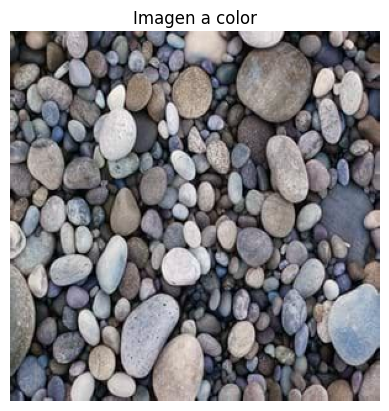

Imagen 1: Tamaño: (300, 300, 3), Tipo de dato: uint8
Imagen 2: Tamaño: (316, 474, 3), Tipo de dato: uint8
Imagen 3: Tamaño: (416, 474, 3), Tipo de dato: uint8
Imagen 4: Tamaño: (681, 474, 3), Tipo de dato: uint8
Imagen 5: Tamaño: (355, 474, 3), Tipo de dato: uint8
Imagen 6: Tamaño: (314, 474, 3), Tipo de dato: uint8
Canales de color de imagen #1:


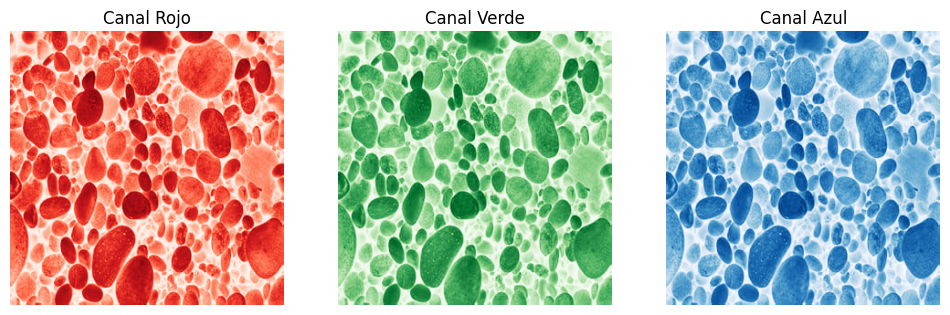

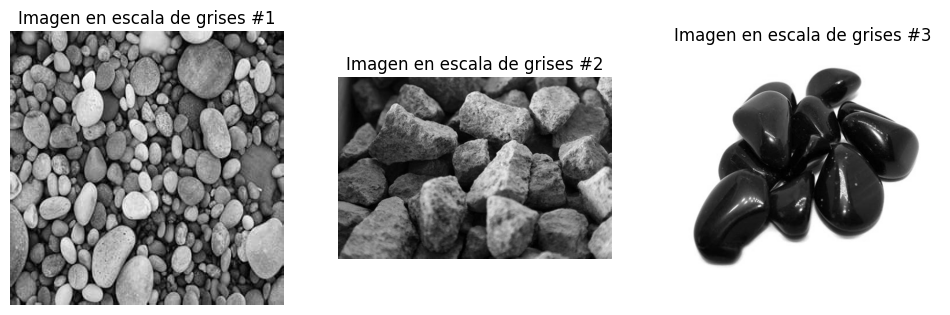

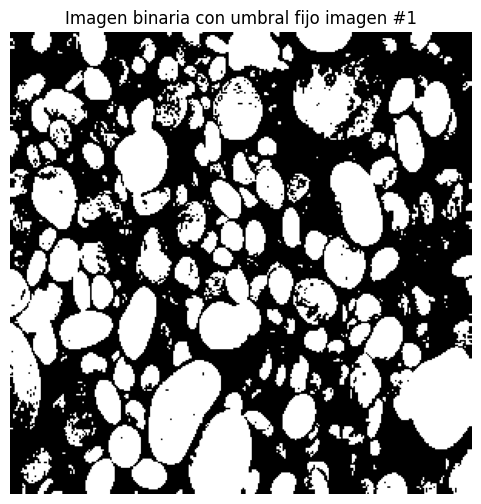

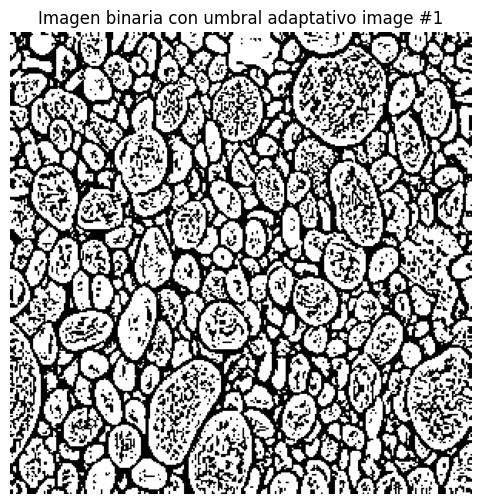

In [17]:
# Cargar y mostrar una imagen a color


# ----------------cargar varias imagenes------------------

# Crear una lista de nombres de archivos de imagen
image_files = [f'assets/real_moon_images/TCAM{i}.png' for i in range(1, 7)]

# Leer las imágenes usando OpenCV
images = [cv2.imread(file) for file in image_files]


# Mostrar la primera imagen
plt.imshow(images[0])
plt.title('Imagen a color')
plt.axis('off')
plt.show()

# Obtener el tamaño y tipo de las imagenes
for i, img in enumerate(images):
    print(f'Imagen {i+1}: Tamaño: {img.shape}, Tipo de dato: {img.dtype}')
        


# mostrar los canales de color de la primera imagen
r,g,b = cv2.split(images[0])
print("Canales de color de imagen #1:")
# canal Rojo
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(r, cmap='Reds')
plt.title('Canal Rojo')
plt.axis('off')

# canal Verde
plt.subplot(1,3,2)
plt.imshow(g, cmap='Greens')
plt.title('Canal Verde')
plt.axis('off')

# canal Azul
plt.subplot(1,3,3)
plt.imshow(b, cmap='Blues')
plt.title('Canal Azul')
plt.axis('off')
plt.show()

# Convertir las imágenes a escala de grises
images_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

# Convertir la imagen a escala de grises
gray_image = [images_gray[0], images_gray[1], images_gray[2]]

# Mostrar las imagen en escala de grises
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(gray_image[0], cmap='gray')
plt.title('Imagen en escala de grises #1')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray_image[1], cmap='gray')
plt.title('Imagen en escala de grises #2')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gray_image[2], cmap='gray')
plt.title('Imagen en escala de grises #3')
plt.axis('off')
plt.show()

# conversion de las imagenes a binario unsando un umbral fijo

binary_images = [cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)[1] for img in images_gray]

plt.figure(figsize=(6,6))
plt.imshow(binary_images[0] , cmap='gray')
plt.title('Imagen binaria con umbral fijo imagen #1')
plt.axis('off')
plt.show()

# binarizacion usando un umbral adaptativo
adaptive_binary_images = [cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                               cv2.THRESH_BINARY, 11, 2) for img in images_gray]     

plt.figure(figsize=(6,6))
plt.imshow(adaptive_binary_images[0] , cmap='gray')
plt.title('Imagen binaria con umbral adaptativo image #1')
plt.axis('off')
plt.show()


# B. Operaciones aritméticas
- Suma 
- Resta 
- Multiplicación
- División 
- Ajuste de brillo.
- Ajuste de contraste.


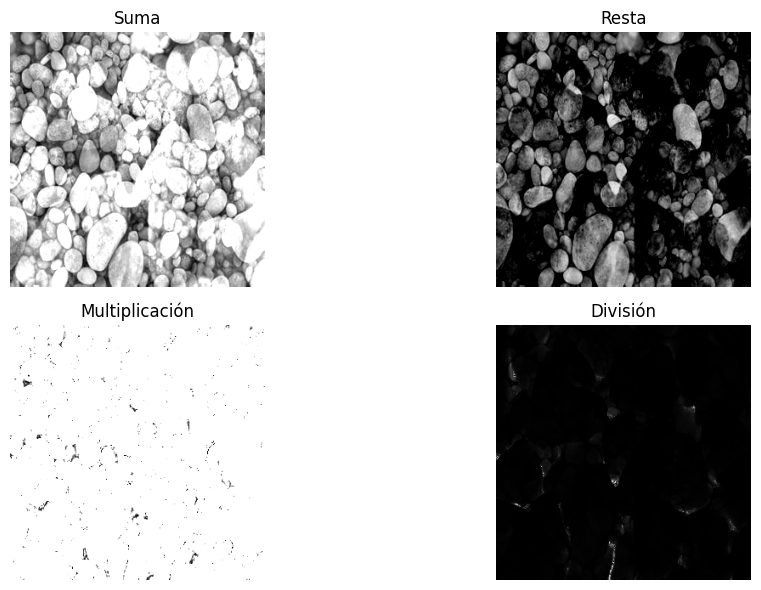

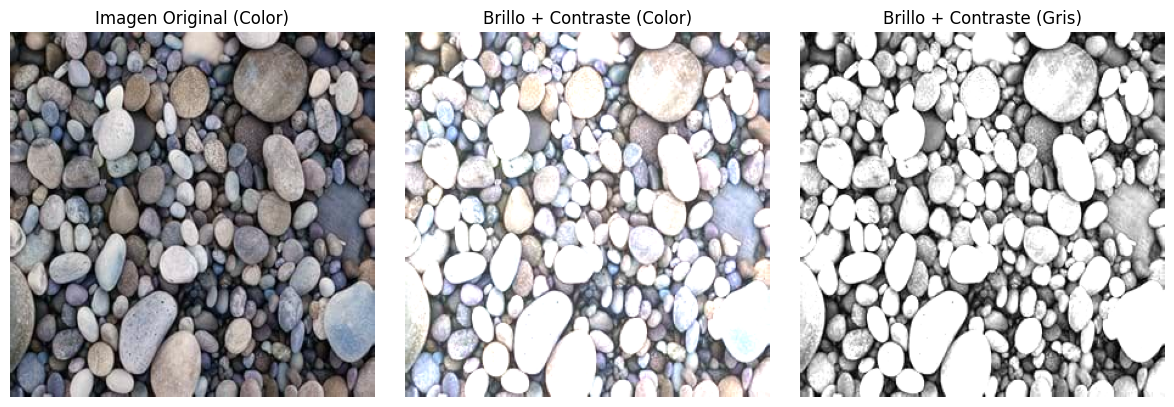

In [18]:
# Select two grayscale images
img1 = images_gray[0]
img2 = images_gray[1]

# Ensure images have the same size
if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Arithmetic operations
# 1. Sum
sum_image = cv2.add(img1, img2)

# 2. Subtraction
sub_image = cv2.subtract(img1, img2)

# 3. Multiplication
mul_image = cv2.multiply(img1, img2)

# 4. Safe Division (avoid division by zero)
div_image = np.zeros_like(img1, dtype=np.float32)
mask = img2 != 0  # Avoid division by zero
div_image[mask] = img1[mask].astype(np.float32) / img2[mask].astype(np.float32)
div_image = np.clip(div_image, 0, 255).astype(np.uint8)  # Convert back to uint8

# Display results in a single 1x3 figure for sum, subtraction, multiplication
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(sum_image, cmap='gray')
plt.title('Suma')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sub_image, cmap='gray')
plt.title('Resta')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(mul_image, cmap='gray')
plt.title('Multiplicación')
plt.axis('off')

# Display division in a separate figure
plt.subplot(2,2,4)
plt.imshow(div_image, cmap='gray')
plt.title('División')
plt.axis('off')

plt.tight_layout()
plt.show()


# Ajuste de brillo y contraste en imágenes a color y en escala de grises

img_rgb = images[0]

# Convertir a escala de grises (opcional, para simplificar ajustes)
img_gray = images_gray[0]

# Ajuste de brillo y contraste
# Parámetros
alpha = 1.5  # Factor de contraste (>1 aumenta, <1 reduce)
beta = 50    # Valor de brillo (positivo aumenta, negativo reduce)

# Ajuste en imagen a color
img_brillo_contraste_color = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)

# Ajuste en imagen en escala de grises
img_brillo_contraste_gray = cv2.convertScaleAbs(img_gray, alpha=alpha, beta=beta)

# Mostrar resultados
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original (Color)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_brillo_contraste_color)
plt.title('Brillo + Contraste (Color)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_brillo_contraste_gray, cmap='gray')
plt.title('Brillo + Contraste (Gris)')
plt.axis('off')

plt.tight_layout()
plt.show()

# C. Operaciones lógicas
- Operación AND entre dos imágenes binarias.
- Operación OR entre dos imágenes binarias.
- Operación XOR entre dos imágenes binarias.
- Operación NOT (inversión).


Imágenes binarias usadas para operaciones lógicas:


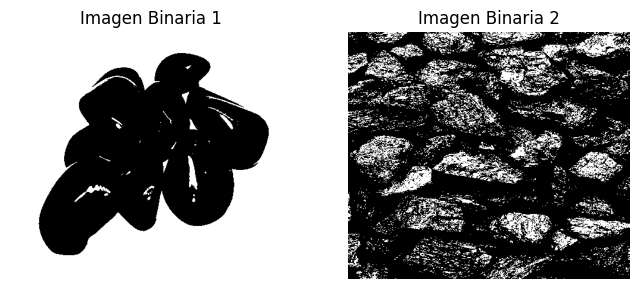

Resultados de las operaciones lógicas:


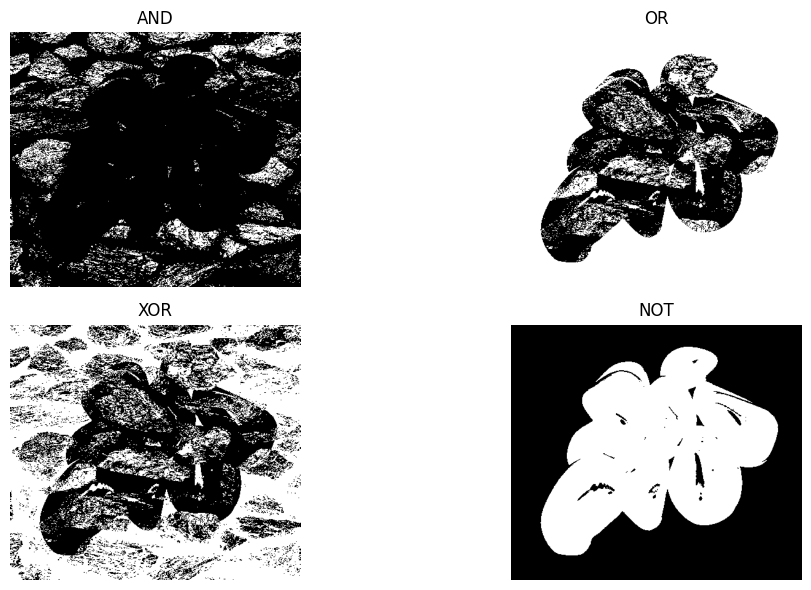

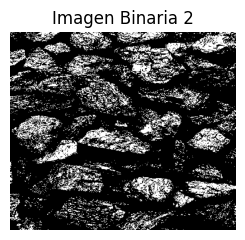

Resultados de las operaciones lógicas:


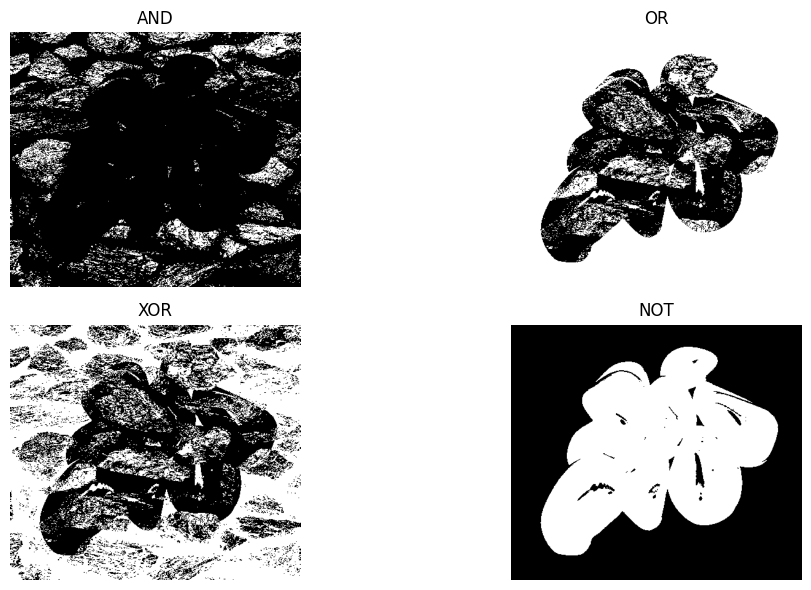

In [20]:
# Obtener imágenes binarias
binary1 = binary_images[2]
binary2 = binary_images[3]

# Asegurar que las imágenes tengan el mismo tamaño
if binary1.shape != binary2.shape:
    binary2 = cv2.resize(binary2, (binary1.shape[1], binary1.shape[0]))

# Verificar que las imágenes sean binarias (0 y 255)
binary1 = cv2.threshold(binary1, 127, 255, cv2.THRESH_BINARY)[1]
binary2 = cv2.threshold(binary2, 127, 255, cv2.THRESH_BINARY)[1]

# Operaciones lógicas
# 1. AND
and_image = cv2.bitwise_and(binary1, binary2)
# 2. OR
or_image = cv2.bitwise_or(binary1, binary2)
# 3. XOR
xor_image = cv2.bitwise_xor(binary1, binary2)
# 4. NOT (inversión) de la primera imagen   
not_image = cv2.bitwise_not(binary1)

# Mostrar imágenes binarias antes del procesamiento
print("Imágenes binarias usadas para operaciones lógicas:")
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(binary1, cmap='gray')
plt.title('Imagen Binaria 1')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(binary2, cmap='gray')
plt.title('Imagen Binaria 2')
plt.axis('off')
plt.show()

# Mostrar resultados
print("Resultados de las operaciones lógicas:")
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(and_image, cmap='gray')
plt.title('AND')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(or_image, cmap='gray')
plt.title('OR')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(xor_image, cmap='gray')
plt.title('XOR')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(not_image, cmap='gray')
plt.title('NOT')
plt.axis('off')
plt.tight_layout()
plt.show()
plt.subplot(1, 2, 2)
plt.imshow(binary2, cmap='gray')
plt.title('Imagen Binaria 2')
plt.axis('off')
plt.show()

print("Resultados de las operaciones lógicas:")
# Mostrar resultados
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(and_image, cmap='gray')
plt.title('AND')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(or_image, cmap='gray')
plt.title('OR')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(xor_image, cmap='gray')
plt.title('XOR')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(not_image, cmap='gray')
plt.title('NOT')
plt.axis('off')

plt.tight_layout()
plt.show()



# D. Filtros espaciales
- Filtro promedio.
- Filtro gaussiano.
- Filtro mediana.
- Filtro laplaciano.
- Detección de bordes con Sobel.
- Detección de bordes con Prewitt.
- Detección de bordes con Canny.


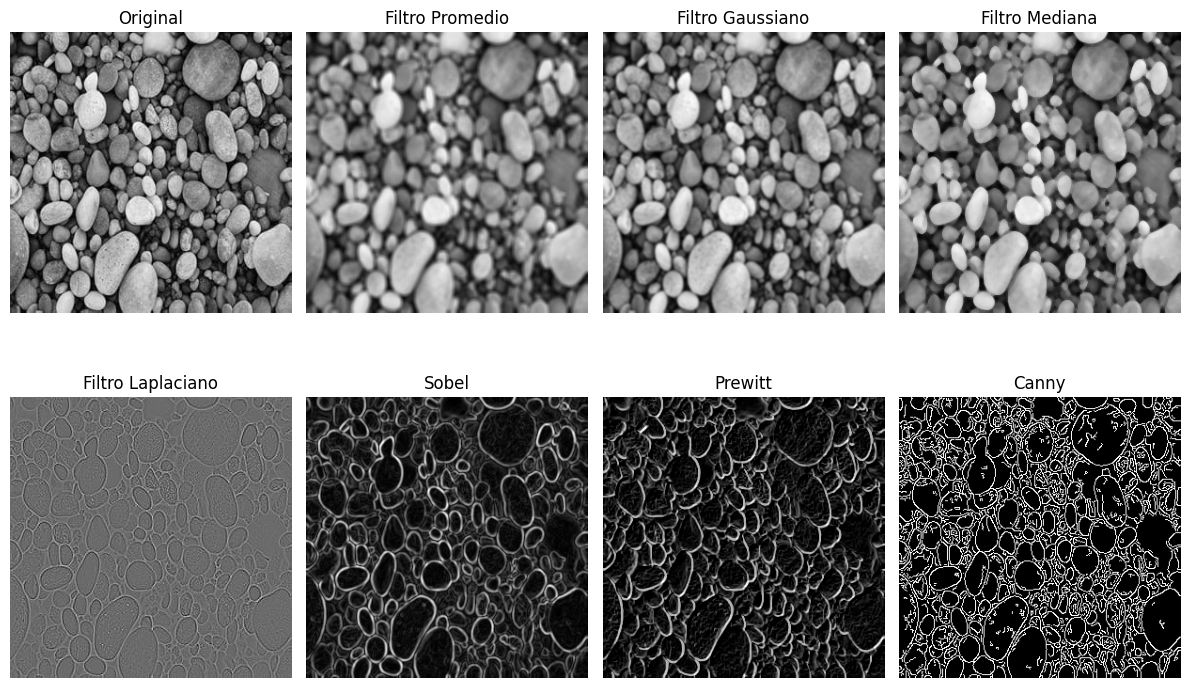

In [21]:
# Aplicar filtros espaciales a una imagen en escala de grises
img_gray = images_gray[0]

# Filtro promedio
mean_filtered = cv2.blur(img_gray, (5, 5))

# Filtro gaussiano
gaussian_filtered = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Filtro mediana
median_filtered = cv2.medianBlur(img_gray, 5)

# Filtro laplaciano
laplacian_filtered = cv2.Laplacian(img_gray, cv2.CV_64F)

# Detección de bordes con Sobel
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5)
sobel_filtered = cv2.magnitude(sobel_x, sobel_y)

# Detección de bordes con Prewitt
kernelx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
kernely = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
prewitt_x = cv2.filter2D(img_gray, -1, kernelx)
prewitt_y = cv2.filter2D(img_gray, -1, kernely) 
# Convert to float32 for cv2.magnitude
prewitt_x_f = prewitt_x.astype(np.float32)
prewitt_y_f = prewitt_y.astype(np.float32)
prewitt_filtered = cv2.magnitude(prewitt_x_f, prewitt_y_f)

# Detección de bordes con Canny
canny_filtered = cv2.Canny(img_gray, 100, 200)

# Mostrar resultados
plt.figure(figsize=(12, 8))
plt.subplot(2, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(2, 4, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title('Filtro Promedio')
plt.axis('off')
plt.subplot(2, 4, 3)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title('Filtro Gaussiano')
plt.axis('off')
plt.subplot(2, 4, 4)
plt.imshow(median_filtered, cmap='gray')
plt.title('Filtro Mediana')
plt.axis('off')
plt.subplot(2, 4, 5)
plt.imshow(laplacian_filtered, cmap='gray')
plt.title('Filtro Laplaciano')
plt.axis('off')
plt.subplot(2, 4, 6)
plt.imshow(sobel_filtered, cmap='gray')
plt.title('Sobel')
plt.axis('off')
plt.subplot(2, 4, 7)
plt.imshow(prewitt_filtered, cmap='gray')
plt.title('Prewitt')
plt.axis('off')
plt.subplot(2, 4, 8)
plt.imshow(canny_filtered, cmap='gray')
plt.title('Canny')
plt.axis('off')
plt.tight_layout()
plt.show()

# E. Operaciones morfológicas
- Erosión.
- Dilatación.
- Apertura.
- Cierre.
- Gradiente morfológico.
- Top-hat.
- Black-hat.


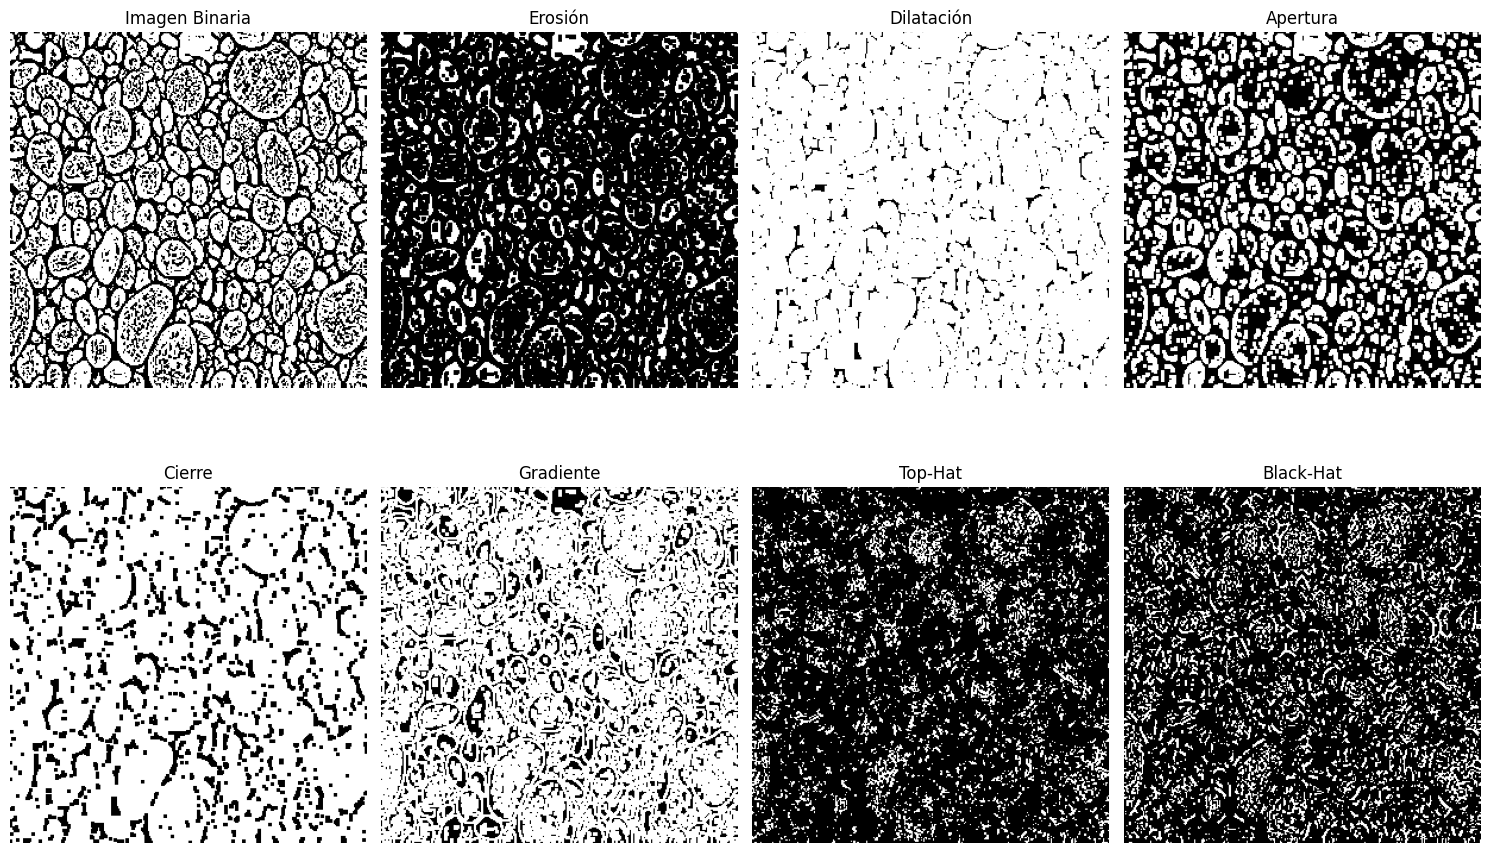

In [22]:
# Operaciones Morfológicas

binary_image1 = adaptive_binary_images[0]
binary_image2 = adaptive_binary_images[1]

# Definir un elemento estructurante (kernel)
kernel = np.ones((3, 3), np.uint8)

# Aplicar operaciones morfológicas
# 1. Erosión
eroded_image = cv2.erode(binary_image1, kernel, iterations=1)

# 2. Dilatación
dilated_image = cv2.dilate(binary_image1, kernel, iterations=1)

# 3. Apertura (Erosión seguida de Dilatación)
opened_image = cv2.morphologyEx(binary_image1, cv2.MORPH_OPEN, kernel)

# 4. Cierre (Dilatación seguida de Erosión)
closed_image = cv2.morphologyEx(binary_image1, cv2.MORPH_CLOSE, kernel)

# 5. Gradiente Morfológico (Diferencia entre Dilatación y Erosión)
gradient_image = cv2.morphologyEx(binary_image1, cv2.MORPH_GRADIENT, kernel)

# 6. Top-Hat (Diferencia entre la imagen original y su apertura)
tophat_image = cv2.morphologyEx(binary_image1, cv2.MORPH_TOPHAT, kernel)

# 7. Black-Hat (Diferencia entre el cierre y la imagen original)
blackhat_image = cv2.morphologyEx(binary_image1, cv2.MORPH_BLACKHAT, kernel)

# Mostrar resultados
plt.figure(figsize=(15, 10))
plt.subplot(2, 4, 1)
plt.imshow(binary_image1, cmap='gray')
plt.title('Imagen Binaria')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(eroded_image, cmap='gray')
plt.title('Erosión')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(dilated_image, cmap='gray')
plt.title('Dilatación')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(opened_image, cmap='gray')
plt.title('Apertura')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(closed_image, cmap='gray')
plt.title('Cierre')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(gradient_image, cmap='gray')
plt.title('Gradiente')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(tophat_image, cmap='gray')
plt.title('Top-Hat')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(blackhat_image, cmap='gray')
plt.title('Black-Hat')
plt.axis('off')

plt.tight_layout()
plt.show()


# F. Filtros morfológicos y segmentación
- Eliminación de ruido en binaria con apertura/cierre.
- Extracción de contornos con morfología.
- Esqueletización.
- Relleno de huecos internos.
- Segmentación por umbral fijo.
- Segmentación adaptativa.
- Segmentación por bordes.
- Segmentación basada en regiones.
- Segmentación con Watershed.


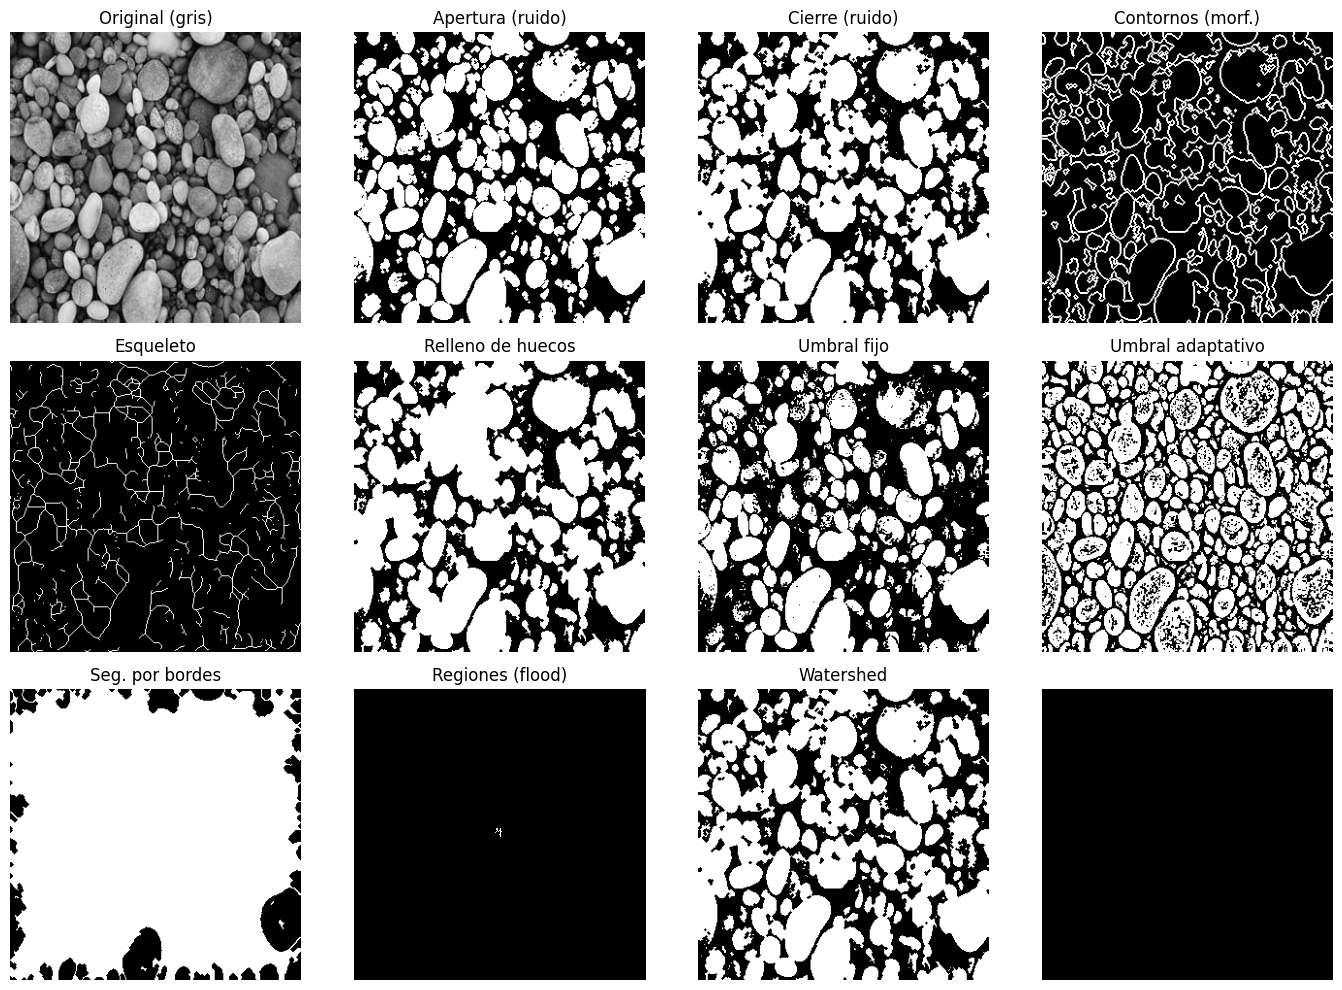

In [23]:
# 1) Seleccionar una sola imagen en escala de grises (ya existe images_gray)
imgg = images_gray[0]

# 2) Umbral base (Otsu) para binarizar antes de morfología
_, base_bw = cv2.threshold(imgg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3) Apertura y Cierre (eliminación de ruido)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
bw_open  = cv2.morphologyEx(base_bw, cv2.MORPH_OPEN,  kernel, iterations=1)
bw_close = cv2.morphologyEx(base_bw, cv2.MORPH_CLOSE, kernel, iterations=1)

# 4) Contornos morfológicos (gradiente morfológico)
bw_grad = cv2.morphologyEx((bw_close>0).astype(np.uint8), cv2.MORPH_GRADIENT, kernel)
bw_grad = (bw_grad*255).astype(np.uint8)

# 5) Esqueletización (sobre binaria)
bw_skel = skeletonize((bw_close>0))
bw_skel = (bw_skel.astype(np.uint8)*255)

# 6) Relleno de huecos internos
bw_filled = ndi.binary_fill_holes((bw_close>0))
bw_filled = (bw_filled.astype(np.uint8)*255)

# 7) Segmentación por umbral fijo (ejemplo t=127)
_, seg_fixed = cv2.threshold(imgg, 127, 255, cv2.THRESH_BINARY)

# 8) Segmentación adaptativa (Gauss)
seg_adapt = cv2.adaptiveThreshold(imgg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 21, 2)

# 9) Segmentación por bordes (Canny -> cierre -> rellenado)
edges = cv2.Canny(imgg, 100, 200)
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
seg_edges = ndi.binary_fill_holes(edges_closed>0).astype(np.uint8)*255

# 10) Segmentación basada en regiones (flood desde el centro)
h, w = imgg.shape[:2]
seed_rc = (h//2, w//2)
seg_region = flood(imgg, seed_point=seed_rc, tolerance=10).astype(np.uint8)*255

# 11) Segmentación con Watershed (marcadores por picos de distancia)
bw_ws_input = (bw_close > 0).astype(np.uint8)
dist = ndi.distance_transform_edt(bw_ws_input)

# picos locales como coordenadas (sin 'indices')
coords = peak_local_max(
    dist,
    labels=bw_ws_input,
    footprint=np.ones((3, 3), dtype=bool),
    exclude_border=False  # opcional según el caso
)

# convertir coordenadas -> máscara booleana
peak_mask = np.zeros_like(bw_ws_input, dtype=bool)
if coords.size > 0:
    peak_mask[coords[:, 0], coords[:, 1]] = True

# etiquetar marcadores y ejecutar watershed
markers, _ = ndi.label(peak_mask)
labels_ws = watershed(-dist, markers, mask=bw_ws_input.astype(bool))
seg_watershed = (labels_ws > 0).astype(np.uint8) * 255

# Mostrar todo en una rejilla
fig, axs = plt.subplots(3, 4, figsize=(14, 10))
axs = axs.ravel()

titles = [
    'Original (gris)',
    'Apertura (ruido)',
    'Cierre (ruido)',
    'Contornos (morf.)',
    'Esqueleto',
    'Relleno de huecos',
    'Umbral fijo',
    'Umbral adaptativo',
    'Seg. por bordes',
    'Regiones (flood)',
    'Watershed',
    ''
]

images_to_show = [
    imgg, bw_open, bw_close, bw_grad, bw_skel, bw_filled,
    seg_fixed, seg_adapt, seg_edges, seg_region, seg_watershed, np.zeros_like(imgg)
]

for ax, img, title in zip(axs, images_to_show, titles):
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

# Ocultar el último subplot vacío si se usa 3x4
axs[-1].axis('off')
plt.tight_layout()
plt.show()


# G. Análisis de propiedades (regionprops)
- Identificación de regiones conectadas.
- Cálculo de área de objetos.
- Cálculo de perímetro de objetos.
- Detección de centroides.
- Orientación de objetos.
- Bounding box de objetos.
- Extracción de varias propiedades simultáneas (área, perímetro, orientación).


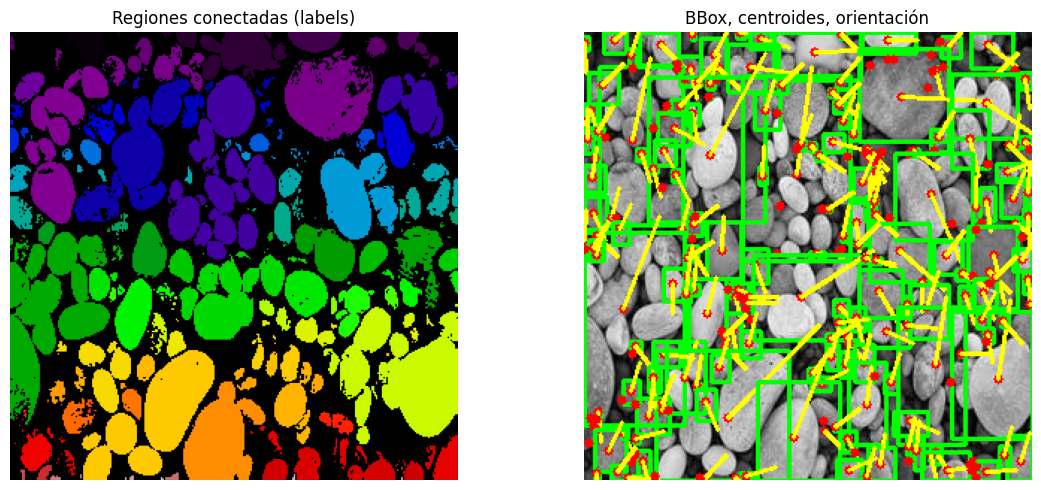

Propiedades (regionprops_table):
     label   area  perimeter  orientation  bbox-0  bbox-1  bbox-2  bbox-3  \
0        1  163.0  47.556349    -0.775785       0      13      14      28   
1        2  381.0  95.662951     0.866351       0      37      22      63   
2        3    8.0   7.000000    -0.151442       0      72       5      74   
3        4   16.0  13.242641    -1.513182       0     102       4     108   
4        5  123.0  43.935029     1.246710       0     111      11     125   
..     ...    ...        ...          ...     ...     ...     ...     ...   
263    264   17.0  13.035534     1.524058     297      27     300      34   
264    265    8.0   7.414214    -0.785398     297      80     300      83   
265    266    2.0   0.000000     0.000000     298      77     300      78   
266    267    3.0   3.414214     0.785398     298     101     300     103   
267    268    2.0   0.000000     0.000000     298     262     300     263   

     centroid-0  centroid-1  
0      5.883

In [24]:
from skimage.measure import label, regionprops_table

# 1) Seleccionar una imagen gris y binarizar (Otsu)
imgg = images_gray[0]  # 2D uint8
_, bw = cv2.threshold(imgg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2) Regiones conectadas con estadísticas (OpenCV)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    (bw > 0).astype(np.uint8), connectivity=8, ltype=cv2.CV_32S
)

# 3) Calcular perímetro y orientación por etiqueta usando contornos y momentos
results = []
overlay = cv2.cvtColor(imgg, cv2.COLOR_GRAY2BGR)

for i in range(1, num_labels):  # omitir fondo 0
    x, y, w, h, area = stats[i, [cv2.CC_STAT_LEFT, cv2.CC_STAT_TOP,
                                 cv2.CC_STAT_WIDTH, cv2.CC_STAT_HEIGHT,
                                 cv2.CC_STAT_AREA]]
    cx, cy = centroids[i]

    # Máscara de la etiqueta i
    mask_i = np.zeros_like(bw, dtype=np.uint8)
    mask_i[labels == i] = 255

    # Contorno principal (externo)
    cnts, _ = cv2.findContours(mask_i, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    peri = np.nan
    theta = np.nan
    if len(cnts) > 0:
        cnt = max(cnts, key=cv2.contourArea)
        # Perímetro (arc length)
        peri = cv2.arcLength(cnt, True)
        # Momentos y orientación
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            mu20, mu02, mu11 = M["mu20"], M["mu02"], M["mu11"]
            theta = 0.5 * np.arctan2(2 * mu11, (mu20 - mu02))

    results.append(dict(
        label=i, area=int(area), perimeter=float(peri) if not np.isnan(peri) else np.nan,
        centroid=(float(cx), float(cy)), orientation=float(theta) if not np.isnan(theta) else np.nan,
        bbox=(int(x), int(y), int(w), int(h))
    ))

    # Dibujar bbox y centroide
    cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.circle(overlay, (int(cx), int(cy)), 3, (0, 0, 255), -1)

    # Dibujar eje de orientación si existe
    if not np.isnan(theta):
        L = max(20, min(w, h))  # longitud de la flecha proporcional al tamaño
        x2 = int(cx + L * np.cos(theta))
        y2 = int(cy + L * np.sin(theta))
        cv2.line(overlay, (int(cx), int(cy)), (x2, y2), (0, 255, 255), 2)

# Mostrar identificación de regiones y overlay
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(labels, cmap='nipy_spectral'); plt.title('Regiones conectadas (labels)'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title('BBox, centroides, orientación'); plt.axis('off')
plt.tight_layout(); plt.show()

# 4) Tabla con varias propiedades (scikit-image regionprops_table)
lbl = label(bw > 0, connectivity=2)
props = regionprops_table(
    lbl,
    properties=('label', 'area', 'perimeter', 'orientation', 'bbox', 'centroid')
)
df_props = pd.DataFrame(props)
print("Propiedades (regionprops_table):")
print(df_props)

# 5) También mostrar DataFrame con los resultados calculados vía OpenCV
print("\nPropiedades (OpenCV contornos/momentos):")
print(pd.DataFrame(results))


# Reconocer rocas en imágenes de luna

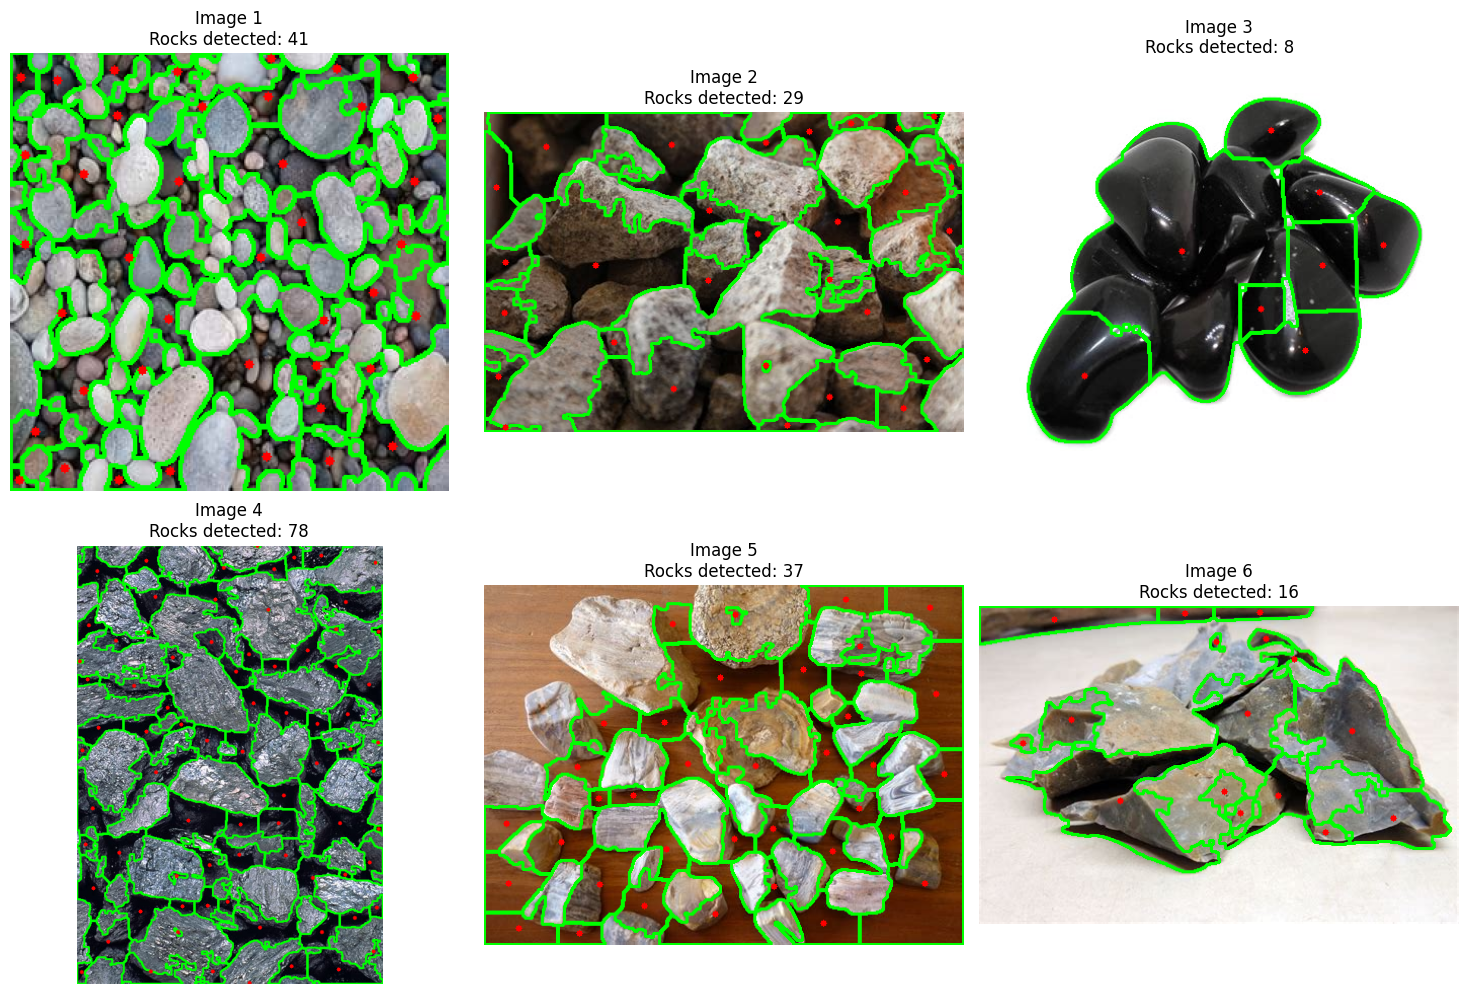


Rock count summary:
--------------------------------------------------
Image 1: 41 rocks detected
Image 2: 29 rocks detected
Image 3: 8 rocks detected
Image 4: 78 rocks detected
Image 5: 37 rocks detected
Image 6: 16 rocks detected


In [35]:
def count_rocks(image_path):
    """
    Count rocks in clean images with white background
    Returns: dictionary with count and visualization
    """
    # Read and prepare image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5,5), 0)
    
    # Threshold to get rocks (dark objects on white background)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Clean up with morphological operations
    kernel = np.ones((3,3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Use distance transform and watershed to separate touching rocks
    dist = ndi.distance_transform_edt(binary)
    dist_smooth = ndi.gaussian_filter(dist, sigma=2)
    
    # Find local maxima for markers
    coords = peak_local_max(dist_smooth, min_distance=20, exclude_border=False)
    markers = np.zeros_like(binary, dtype=np.int32)
    markers[coords[:, 0], coords[:, 1]] = np.arange(1, len(coords) + 1)
    
    # Apply watershed
    labels = watershed(-dist_smooth, markers, mask=binary)
    
    # Count unique labels (excluding background)
    rock_count = len(np.unique(labels)) - 1
    
    # Create visualization
    vis = img.copy()
    
    # Draw contours for each rock
    for label in range(1, rock_count + 1):
        mask = (labels == label).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)
        
        # Get centroid
        M = cv2.moments(contours[0])
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            # Draw rock number
            cv2.circle(vis, (cx, cy), 3, (0, 0, 255), -1)
    
    return {
        'count': rock_count,
        'visualization': vis
    }

# Process all images
image_files = [f'assets/real_moon_images/TCAM{i}.png' for i in range(1, 7)]
results = []

plt.figure(figsize=(15, 10))
for idx, img_path in enumerate(image_files, 1):
    result = count_rocks(img_path)
    results.append(result)
    
    plt.subplot(2, 3, idx)
    plt.imshow(cv2.cvtColor(result['visualization'], cv2.COLOR_BGR2RGB))
    plt.title(f'Image {idx}\nRocks detected: {result["count"]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print summary
print("\nRock count summary:")
print("-" * 50)
for idx, result in enumerate(results, 1):
    print(f"Image {idx}: {result['count']} rocks detected")